* https://developer.apple.com/metal/tensorflow-plugin/
* https://www.youtube.com/watch?v=w2qlou7n7MA
* https://github.com/conda-forge/miniforge
* https://github.com/jeffheaton/t81_558_deep_learning/blob/master/install/tensorflow-install-mac-metal-jul-2021.ipynb
* https://github.com/jeffheaton/t81_558_deep_learning/blob/master/tensorflow-apple-metal.yml
* https://github.com/GPflow/GPflow
* `jupytext --to notebook regression.pct.py`

In [1]:
#pip install covasim gpflow

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_probability as tfp
import gpflow as gpf
from gpflow.utilities import print_summary

# The lines below are specific to the notebook format
%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 6)

dtyp = np.float64
gpf.config.set_default_float(dtyp)

print("Tensorflow version " + tf.__version__)
print(f"Tensorflow Probability: {tfp.__version__}")
print(f"GPFlow {gpf.__version__}")
gpu = len(tf.config.list_physical_devices('GPU'))>0
print("GPU is", "available" if gpu else "NOT AVAILABLE")

try:
  tpu = tf.distribute.cluster_resolver.TPUClusterResolver()  # TPU detection
  print('Running on TPU ', tpu.cluster_spec().as_dict()['worker'])

  tf.config.experimental_connect_to_cluster(tpu)
  tf.tpu.experimental.initialize_tpu_system(tpu)
  tpu_strategy = tf.distribute.experimental.TPUStrategy(tpu)
except ValueError:
  msg = 'WARNING: Not connected to a TPU runtime; please see the previous cell in this notebook for instructions!'
  print(msg)

tf.config.experimental.set_visible_devices([], 'GPU') # Turn off GPU (for M1 Mac, hopefully temporary!)
#tf.config.set_soft_device_placement(True)
tf.debugging.set_log_device_placement(False)

print('Physical: ', tf.config.list_physical_devices())
print('Logical: ', tf.config.list_logical_devices())

Tensorflow version 2.8.0
Tensorflow Probability: 0.16.0
GPFlow 2.4.0
GPU is available
Physical:  [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Logical:  [LogicalDevice(name='/device:CPU:0', device_type='CPU')]


## Load training data

In [3]:
df = pd.read_csv('sweep_beta_popinf.csv')
df['log_popinf'] = np.log10(df['pop_infected'])
X1 = df['log_beta']
X2 = df['pop_infected']
X = df[['log_beta', 'pop_infected']].values.reshape(-1, 2).astype(dtyp)
Y = df['cum_inf'].values.reshape(-1, 1).astype(dtyp)

# Normalize
Y = Y-Y.mean()
Y = 2 * Y / (Y.max() - Y.min())

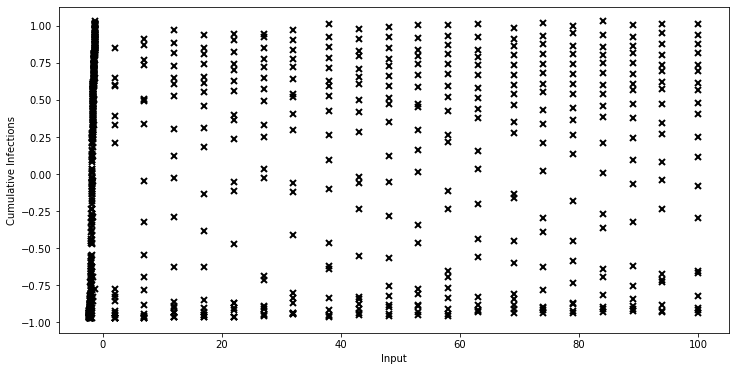

In [4]:
f, ax = plt.subplots();
ax.plot(X, Y, 'kx', mew=2);
ax.set_xlabel('Input');
ax.set_ylabel('Cumulative Infections');

In [5]:
likelihood = gpf.likelihoods.HeteroskedasticTFPConditional(
    distribution_class=tfp.distributions.Normal,  # Gaussian Likelihood
    scale_transform=tfp.bijectors.Exp(),  # Exponential Transform
)

print(f"Likelihood's expected latent_dim: {likelihood.latent_dim}")

Likelihood's expected latent_dim: 2


In [6]:
def plot_distribution(X, Y, loc, scale):
    plt.figure(figsize=(15, 5))
    x = X.squeeze()
    for k in (1, 2):
        lb = (loc - k * scale).squeeze()
        ub = (loc + k * scale).squeeze()
        plt.fill_between(x, lb, ub, color="silver", alpha=1 - 0.05 * k ** 3)
    plt.plot(x, lb, color="silver")
    plt.plot(x, ub, color="silver")
    plt.plot(X, loc, color="black")
    plt.scatter(X, Y, color="gray", alpha=0.8)
    plt.show()
    plt.close()

In [7]:
kernel = gpf.kernels.SeparateIndependent(
    [
        gpf.kernels.Matern52(lengthscales=[0.3, 200]),  # This is k1, the kernel of f1
        gpf.kernels.SquaredExponential(lengthscales=[0.3, 200]),  # this is k2, the kernel of f2
    ]
)
# The number of kernels contained in gpf.kernels.SeparateIndependent must be the same as likelihood.latent_dim

In [8]:
M = 25  # Number of inducing variables for each f_i

# Initial inducing points position Z
Z1 = np.linspace(X1.min(), X1.max(), M) 
Z2 = np.linspace(X2.min(), X2.max(), M)
Z = np.stack([Z1, Z2]).T # Z must be of shape [M, 2]

inducing_variable = gpf.inducing_variables.SeparateIndependentInducingVariables(
    [
        gpf.inducing_variables.InducingPoints(Z),  # This is U1 = f1(Z)
        gpf.inducing_variables.InducingPoints(Z),  # This is U2 = f2(Z)
    ]
)

In [9]:
model = gpf.models.SVGP(
    kernel=kernel,
    likelihood=likelihood,
    inducing_variable=inducing_variable,
    num_latent_gps=likelihood.latent_dim,
)

#model.kernel.kernels[0].lengthscales = [0.3, 200]

display(model)

Ymean, Yvar = model.predict_y(Xnew=X)#, full_cov=False)
Ymean = Ymean.numpy().squeeze()
Ystd = tf.sqrt(Yvar).numpy().squeeze()
#plot_distribution(X, Y, Ymean, Ystd)

name,class,transform,prior,trainable,shape,dtype,value
SVGP.kernel.kernels[0].variance,Parameter,Softplus,,True,(),float64,1.0
SVGP.kernel.kernels[0].lengthscales,Parameter,Softplus,,True,"(2,)",float64,[ 0.3 200. ]
SVGP.kernel.kernels[1].variance,Parameter,Softplus,,True,(),float64,1.0
SVGP.kernel.kernels[1].lengthscales,Parameter,Softplus,,True,"(2,)",float64,[ 0.3 200. ]
SVGP.inducing_variable.inducing_variable_list[0].Z,Parameter,Identity,,True,"(25, 2)",float64,"[[-2.25, 2...."
SVGP.inducing_variable.inducing_variable_list[1].Z,Parameter,Identity,,True,"(25, 2)",float64,"[[-2.25, 2...."
SVGP.q_mu,Parameter,Identity,,True,"(25, 2)",float64,"[[0., 0...."
SVGP.q_sqrt,Parameter,FillTriangular,,True,"(2, 25, 25)",float64,"[[[1., 0., 0...."


In [10]:
data = (X, Y)
loss_fn = model.training_loss_closure(data)

gpf.utilities.set_trainable(model.q_mu, False)
gpf.utilities.set_trainable(model.q_sqrt, False)

variational_vars = [(model.q_mu, model.q_sqrt)]
natgrad_opt = gpf.optimizers.NaturalGradient(gamma=0.1)

adam_vars = model.trainable_variables
adam_opt = tf.optimizers.Adam(0.01)


@tf.function
def optimisation_step():
    #with tf.device('CPU:0'):
    natgrad_opt.minimize(loss_fn, variational_vars)
    adam_opt.minimize(loss_fn, adam_vars)

2022-04-06 00:16:20.808034: W tensorflow/python/util/util.cc:368] Sets are not currently considered sequences, but this may change in the future, so consider avoiding using them.


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: invalid value for "node": expected "ast.AST", got "<class 'NoneType'>"; to visit lists of nodes, use "visit_block" instead
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: invalid value for "node": expected "ast.AST", got "<class 'NoneType'>"; to visit lists of nodes, use "visit_block" instead
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Instructions for updating:
Use fn_output_signature instead


2022-04-06 00:16:23.807135: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


Epoch 2500 - Loss: -581.9046
Epoch 5000 - Loss: -627.9790
Epoch 7500 - Loss: -657.2997
Epoch 10000 - Loss: -676.0688


name,class,transform,prior,trainable,shape,dtype,value
SVGP.kernel.kernels[0].variance,Parameter,Softplus,,True,(),float64,0.5042235107942505
SVGP.kernel.kernels[0].lengthscales,Parameter,Softplus,,True,"(2,)",float64,[ 0.70144496 248.08130622]
SVGP.kernel.kernels[1].variance,Parameter,Softplus,,True,(),float64,18.90130782806614
SVGP.kernel.kernels[1].lengthscales,Parameter,Softplus,,True,"(2,)",float64,[ 0.34500008 116.05557805]
SVGP.inducing_variable.inducing_variable_list[0].Z,Parameter,Identity,,True,"(25, 2)",float64,"[[-2.50531169, 2.81437044..."
SVGP.inducing_variable.inducing_variable_list[1].Z,Parameter,Identity,,True,"(25, 2)",float64,"[[-2.49810545, 0.35047351..."
SVGP.q_mu,Parameter,Identity,,False,"(25, 2)",float64,"[[-1.24435591, -1.09236875..."
SVGP.q_sqrt,Parameter,FillTriangular,,False,"(2, 25, 25)",float64,"[[[1.82783967e-01, 0.00000000e+00, 0.00000000e+00..."


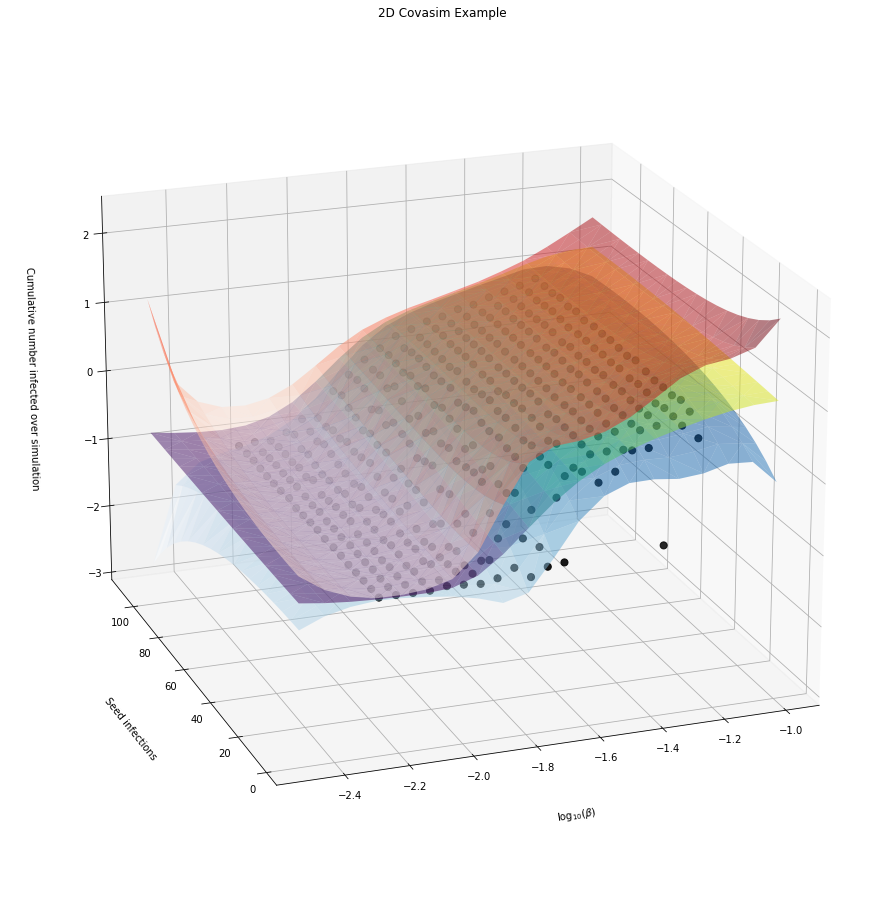

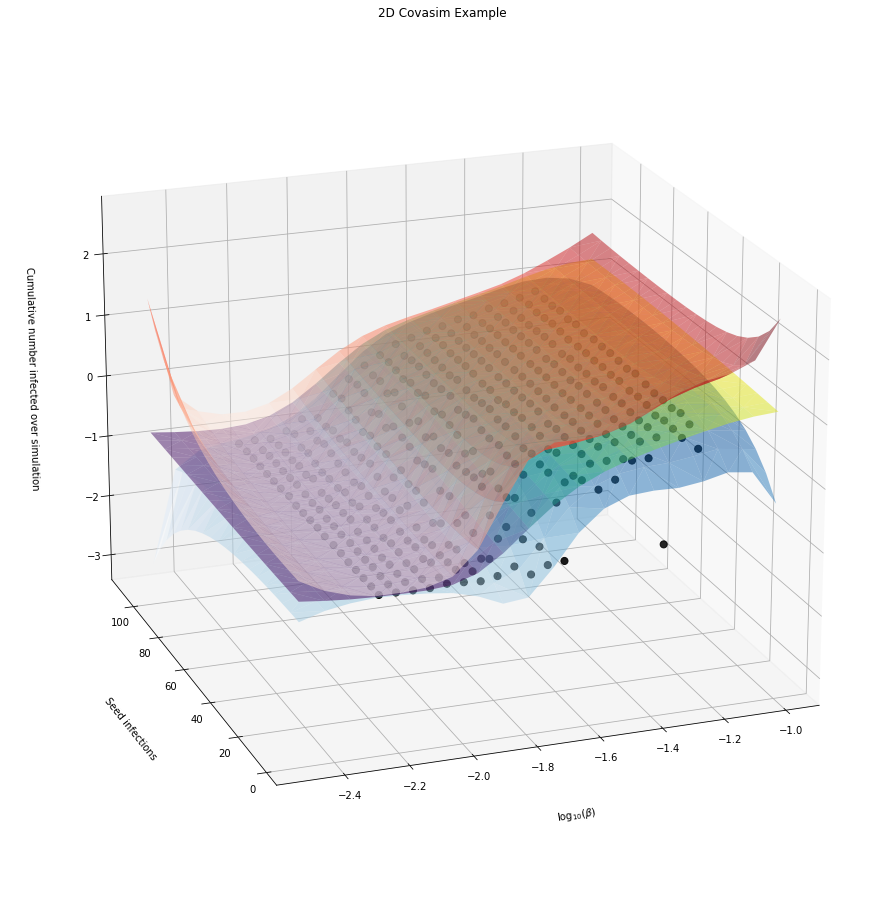

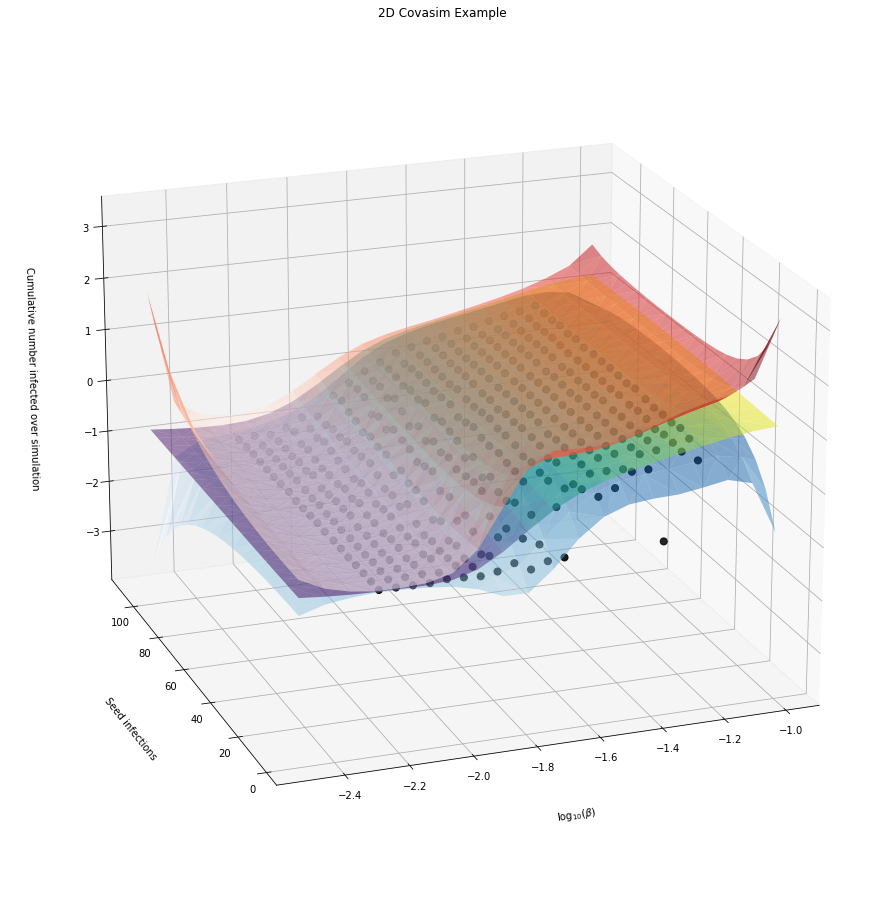

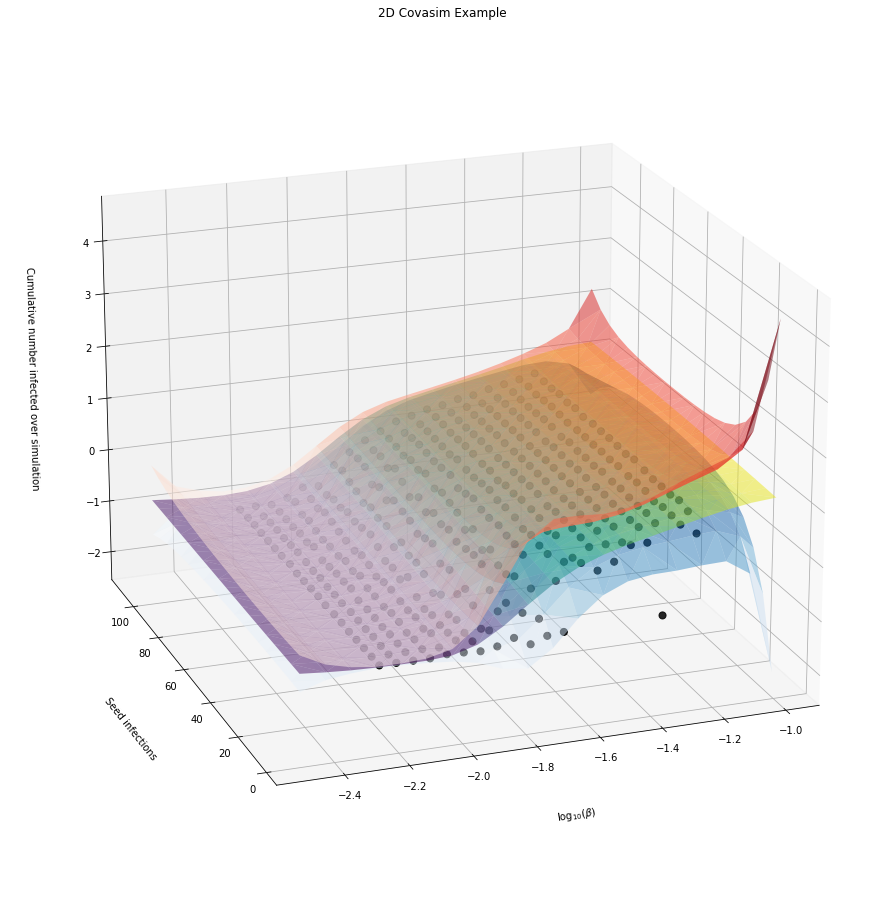

In [11]:
epochs = 10000 # 100
log_freq = int(epochs/4) # 20

N = 20
x1 = np.log10(np.logspace(-2.5, -1, N))  # test points must be of shape (N, D)
x2 = np.linspace(1, 110, N)  # test points must be of shape (N, D)
XX1, XX2 = np.meshgrid(x1, x2)
xx = np.stack([np.ravel(XX1), np.ravel(XX2)]).T.astype(dtyp)

for epoch in range(1, epochs + 1):
    optimisation_step()

    # For every 'log_freq' epochs, print the epoch and plot the predictions against the data
    if epoch % log_freq == 0 and epoch > 0:
        print(f"Epoch {epoch} - Loss: {loss_fn().numpy() : .4f}")
        ## predict mean and variance of latent GP at test points
        #mean_f, var_f = model.predict_f(xx)
        mean_y, var_y = model.predict_y(xx)

        mu = mean_y.numpy().squeeze()
        std_f = np.sqrt(var_y.numpy()).squeeze()
        y = Y.squeeze()

        #plot_distribution(X, Y, Ymean, Ystd)

        fig = plt.figure(figsize=(16,16))
        ax = plt.axes(projection='3d')
        ax.scatter3D(X1, X2, Y, c='black', s=50)
        ax.plot_trisurf(xx[:, 0], xx[:, 1], mean_y.numpy().squeeze(), cmap='viridis', edgecolor='none', alpha=0.5)
        ax.plot_trisurf(xx[:, 0], xx[:, 1], mean_y.numpy().squeeze()+2*np.sqrt(var_y.numpy().squeeze()), cmap='Reds', edgecolor='none', alpha=0.5)
        ax.plot_trisurf(xx[:, 0], xx[:, 1], mean_y.numpy().squeeze()-2*np.sqrt(var_y.numpy().squeeze()), cmap='Blues', edgecolor='none', alpha=0.5)
        #ax.plot_trisurf(X1, X2, np.ravel(mean_f.numpy()), cmap='viridis', edgecolor='none', alpha=0.5)

        ax.view_init(20, 250)
        ax.set_title('2D Covasim Example')
        ax.set_xlabel(r'$\log_{10}(\beta)$')
        ax.set_ylabel('Seed infections')
        ax.set_zlabel('Cumulative number infected over simulation')
        ax.xaxis.labelpad = 30
        ax.yaxis.labelpad = 30
        ax.zaxis.labelpad = 30

display(model)

Percent of points within two standard deviations: 98.0%.


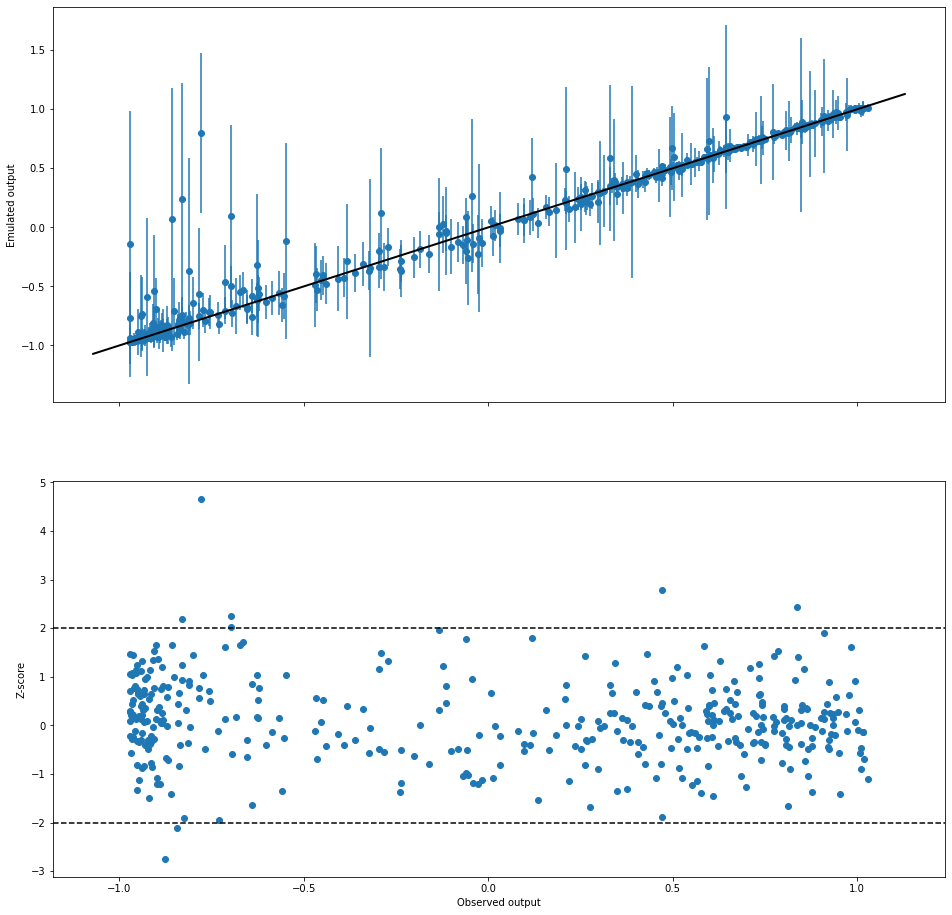

In [12]:
mu, var_f = model.predict_y(Xnew=X)
mu = mu.numpy().squeeze()
std_f = np.sqrt(var_f.numpy()).squeeze()
y = Y.squeeze()

fig, axv = plt.subplots(2,1, figsize=(16,16), sharex=True)

ax = axv[0]
ax.scatter(Y, mu)
ax.errorbar(x=y, y=mu, yerr=2*std_f, fmt='none')
#ax.set_xlim(ax.get_ylim())
#ax.plot([0, 1], [0, 1], transform=ax.transAxes, color='k', lw=2)
xl = ax.get_xlim()
ax.plot(xl, xl, color='k', lw=2) # #, transform=ax.transAxes

ax.set_ylabel('Emulated output')

ax = axv[1]
z = (mu-y) / std_f

ax.scatter(y, z)
ax.axhline(y=-2, color='k', ls='--')
ax.axhline(y=2, color='k', ls='--')
ax.set_xlabel('Observed output')
ax.set_ylabel('Z-score')

print(f'Percent of points within two standard deviations: {sum(abs(z)<2) / len(z):.1%}.');